<a href="https://colab.research.google.com/github/gauravprajapati9210/Machine-Learning-Projects/blob/main/Credit_wise_loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# import depandencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [21]:
df = pd.read_csv("/content/loan_approval_data.csv")
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [22]:
print(df.describe())


       Applicant_ID  Applicant_Income  Coapplicant_Income         Age  \
count    950.000000        950.000000          950.000000  950.000000   
mean     501.220000      10852.571579         5082.455789   39.971579   
std      289.608451       5061.632859         2943.161570   11.139797   
min        1.000000       2009.000000            1.000000   21.000000   
25%      250.250000       6730.750000         2472.750000   30.250000   
50%      499.500000      10548.000000         5205.500000   40.000000   
75%      752.750000      15190.000000         7620.750000   49.000000   
max     1000.000000      19988.000000         9996.000000   59.000000   

       Dependents  Credit_Score  Existing_Loans   DTI_Ratio       Savings  \
count  950.000000    950.000000      950.000000  950.000000    950.000000   
mean     1.474737    676.033684        1.950526    0.347263   9940.452632   
std      1.105067     71.346015        1.406246    0.144341   5860.736885   
min      0.000000    550.000000   

Handling Missing values


In [23]:
categrorical_col = df.select_dtypes(include=["object"]).columns
numerical_col = df.select_dtypes(include=["number"]).columns

In [24]:
from sklearn.impute import SimpleImputer #use to fill missing values with mean or most frequent values or strategy
num_imp = SimpleImputer(strategy="mean")
df[numerical_col]= num_imp.fit_transform(df[numerical_col]) # it work with all columns at a time according to its own columns

In [25]:
df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,50
Age,0
Marital_Status,50
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


In [26]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categrorical_col] = cat_imp.fit_transform(df[categrorical_col])

In [27]:
df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,0
Age,0
Marital_Status,0
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


Exproratory Data Analysis EDA


In [28]:
# Now we are looking that how our classes are balanced

classes_count=df["Loan_Approved"].value_counts()

Text(0.5, 1.0, 'Loan approved or not')

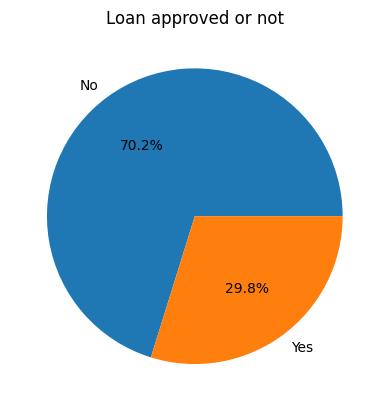

In [29]:
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Loan approved or not")

This is an Imbalanced data set

Text(0.5, 1.0, 'Gender')

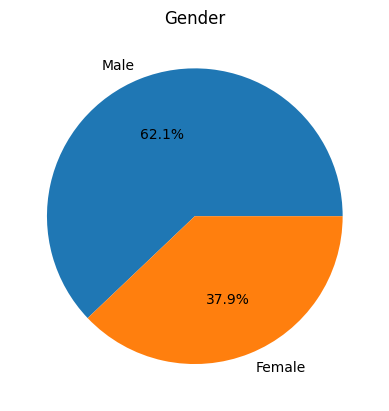

In [30]:
#analysis of categories
gender_count = df["Gender"].value_counts()
plt.pie(gender_count,labels=["Male","Female"],autopct="%1.1f%%")
plt.title("Gender")

Text(0.5, 1.0, 'Income ')

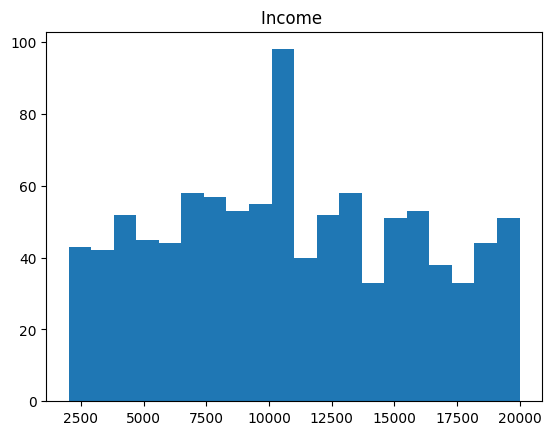

In [31]:
#Analysis of income by histogram
plt.hist(df["Applicant_Income"],bins=20)
plt.title("Income ")

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

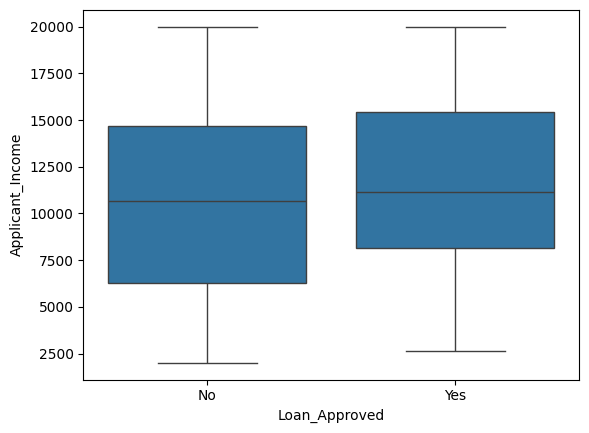

In [32]:
sns.boxplot(data=df,
        x="Loan_Approved",
       y="Applicant_Income"
            )

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

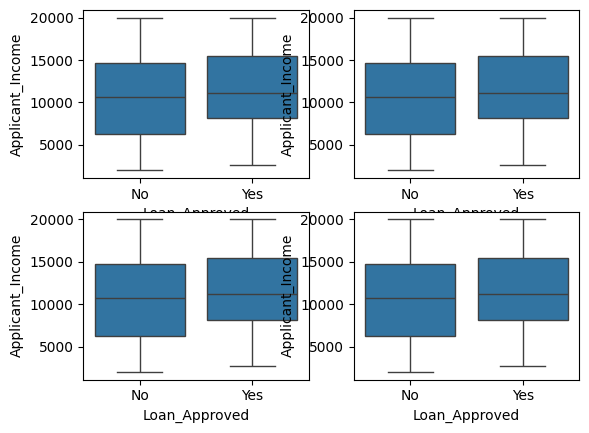

In [33]:
fig,axes=plt.subplots(2,2)

sns.boxplot(data=df,
        x="Loan_Approved",
       y="Applicant_Income",
       ax=axes[0,0]
            )
sns.boxplot(data=df,
        x="Loan_Approved",
       y="Applicant_Income",
       ax=axes[0,1]
            )
sns.boxplot(data=df,
        x="Loan_Approved",
       y="Applicant_Income",
       ax=axes[1,0]
            )
sns.boxplot(data=df,
        x="Loan_Approved",
       y="Applicant_Income",
       ax=axes[1,1]
            )

<Axes: xlabel='Credit_Score', ylabel='Count'>

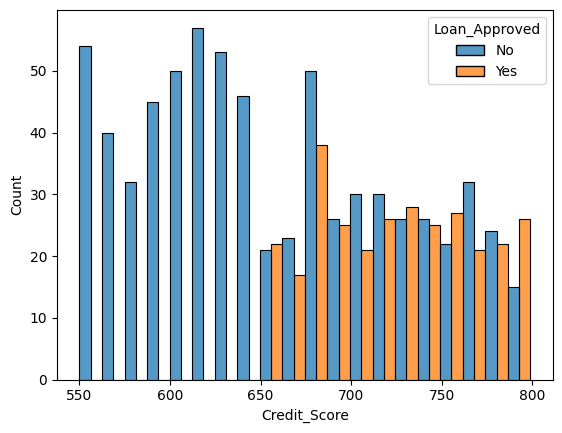

In [34]:
# Credit_Score with loan approval
sns.histplot(data=df,
             x="Credit_Score",
             hue="Loan_Approved",
             bins=20,
             multiple="dodge"
             )

<Axes: xlabel='Applicant_Income', ylabel='Count'>

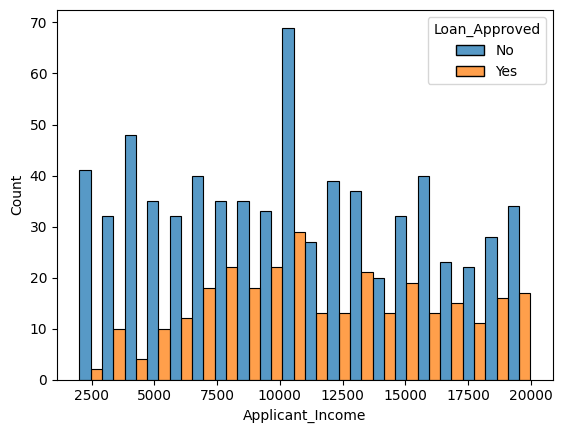

In [36]:
sns.histplot(data=df,
             x="Applicant_Income",
             hue="Loan_Approved",
             bins=20,
             multiple="dodge"
             )

In [40]:
#Removing useless features
# df = df.drop(["Applicant_ID"],axis=1)
# df.head()

KeyError: "['Applicant_ID'] not found in axis"

In [41]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [63]:
#Feature Engineering - LabelEncoder(use for ordinal value) and OneHotEncoding(use for nominal -> every category is important)
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])




In [66]:
# OneHotEncoder
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

# encoded=ohe.fit_transform(df[cols])

# encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

# df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)


In [71]:
df.describe()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,...,0.181000,0.190000,0.178000,0.189000,0.517000,0.621000,0.202000,0.144000,0.422000,0.097000
std,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,...,0.385211,0.392497,0.382704,0.391705,0.499961,0.485381,0.401693,0.351265,0.494126,0.296106
min,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Corelation Heatmap -  Its is a visual representation of the relationships between different numerical variables in dataset

heatmap check for linear relationships

Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

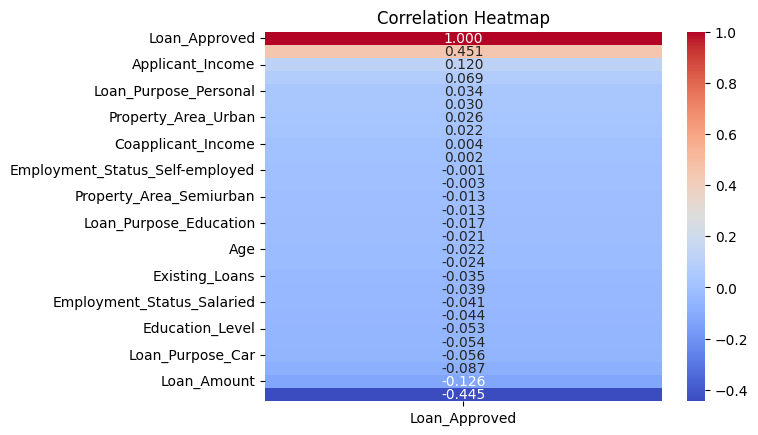

In [84]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
sns.heatmap(corr_matrix.to_frame(),annot=True,fmt="0.3f",cmap="coolwarm")
plt.title("Correlation Heatmap")


In [88]:
x=df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]
y.head()

,Loan_Approved
0,0
1,0
2,1
3,0
4,1


Train and Test split



In [95]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=45)
x_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
791,17524.0,987.0,39.000000,1.474737,688.0,2.0,0.16,9691.0,15295.0,3708.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
143,13649.0,9126.0,39.971579,1.000000,618.0,4.0,0.46,10720.0,28013.0,17979.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
880,13053.0,340.0,37.000000,2.000000,613.0,4.0,0.15,19762.0,26189.0,21545.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
339,15407.0,2353.0,25.000000,1.000000,618.0,4.0,0.38,19171.0,34248.0,5722.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
992,19939.0,7993.0,39.971579,2.000000,766.0,2.0,0.28,6680.0,47037.0,2848.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [96]:
#Feature Selection and standerd data scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [97]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
lr = LogisticRegression()
lr.fit(x_train_scaled,y_train)
y_pred = lr.predict(x_test_scaled)

# Evaluation
print(f"Accuracy Score : {accuracy_score(y_test,y_pred) * 100} %")
print(f"Precision Score : {precision_score(y_test,y_pred) * 100} %")
print(f"Recall Score : {recall_score(y_test,y_pred) * 100} %")
print(f"F1 Score : {f1_score(y_test,y_pred) * 100} %")

Accuracy Score : 88.5 %
Precision Score : 87.5 %
Recall Score : 71.1864406779661 %
F1 Score : 78.50467289719626 %


In [110]:
#kNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=15)

knn_model.fit(x_train_scaled,y_train)
y_pred = knn_model.predict(x_test_scaled)

# Evaluation
print(f"Accuracy Score : {accuracy_score(y_test,y_pred) * 100} %")
print(f"Precision Score : {precision_score(y_test,y_pred) * 100} %")
print(f"Recall Score : {recall_score(y_test,y_pred) * 100} %")
print(f"F1 Score : {f1_score(y_test,y_pred) * 100} %")


Accuracy Score : 81.5 %
Precision Score : 92.3076923076923 %
Recall Score : 40.67796610169492 %
F1 Score : 56.470588235294116 %


In [115]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred = nb_model.predict(x_test_scaled)

# Evaluation
print(f"Accuracy Score : {accuracy_score(y_test,y_pred) * 100} %")
print(f"Precision Score : {precision_score(y_test,y_pred) * 100} %")
print(f"Recall Score : {recall_score(y_test,y_pred) * 100} %")
print(f"F1 Score : {f1_score(y_test,y_pred) * 100} %")

Accuracy Score : 88.5 %
Precision Score : 89.13043478260869 %
Recall Score : 69.49152542372882 %
F1 Score : 78.0952380952381 %


In [130]:
#Add transform features
df["Credit_Score_sq"] = df["Credit_Score"] **2
df["DTI_Ratio_sq"]=df["DTI_Ratio"] **2
df["Applicant_Income_log"]=np.log(df["Applicant_Income"])

x=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio","Applicant_Income"])
y = df["Loan_Approved"]

#Train Test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=45)

# Scaling
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [132]:
# Logistic Regression after some feature Engineering
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
lr = LogisticRegression()
lr.fit(x_train_scaled,y_train)
y_pred = lr.predict(x_test_scaled)

# Evaluation
print(f"Accuracy Score : {accuracy_score(y_test,y_pred) * 100} %")
print(f"Precision Score : {precision_score(y_test,y_pred) * 100} %")
print(f"Recall Score : {recall_score(y_test,y_pred) * 100} %")
print(f"F1 Score : {f1_score(y_test,y_pred) * 100} %")

Accuracy Score : 89.0 %
Precision Score : 84.90566037735849 %
Recall Score : 76.27118644067797 %
F1 Score : 80.35714285714286 %


In [133]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=15)

knn_model.fit(x_train_scaled,y_train)
y_pred = knn_model.predict(x_test_scaled)

# Evaluation
print(f"Accuracy Score : {accuracy_score(y_test,y_pred) * 100} %")
print(f"Precision Score : {precision_score(y_test,y_pred) * 100} %")
print(f"Recall Score : {recall_score(y_test,y_pred) * 100} %")
print(f"F1 Score : {f1_score(y_test,y_pred) * 100} %")


Accuracy Score : 83.5 %
Precision Score : 96.42857142857143 %
Recall Score : 45.76271186440678 %
F1 Score : 62.06896551724138 %


In [134]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred = nb_model.predict(x_test_scaled)

# Evaluation
print(f"Accuracy Score : {accuracy_score(y_test,y_pred) * 100} %")
print(f"Precision Score : {precision_score(y_test,y_pred) * 100} %")
print(f"Recall Score : {recall_score(y_test,y_pred) * 100} %")
print(f"F1 Score : {f1_score(y_test,y_pred) * 100} %")

Accuracy Score : 90.0 %
Precision Score : 88.23529411764706 %
Recall Score : 76.27118644067797 %
F1 Score : 81.81818181818183 %


Now here we can analysis that our Naive bayes is performing best than other model